# 02 · Multi-target TF-IDF + Ridge baseline (Days 1-4)

Exploratory baseline predicting all four WASSA CONV-Turn targets — Emotion,
EmotionalPolarity, Empathy, SelfDisclosure — from a single turn's text with
TF-IDF features and per-target Ridge regression.

**Purpose in the thesis.** Establishes the initial baseline pipeline and
answers two research questions:

- **RQ1** — Can these targets be predicted from a single turn? A linear model
  over word/bigram features gives an honest floor on how much signal a lone
  utterance carries.
- **RQ3** — Which words matter? Ridge coefficients are directly readable, so we
  can list the n-grams that push each target up or down.

**Scope note.** The final canonical baseline (Empathy-only, tuned
hyperparameters) lives in `03_baseline_empathy_only.ipynb`. This notebook is
kept for the multi-target results and the RQ3 coefficient analysis.

**Design decisions documented here:**

- Internal conversation-grouped 70/15/15 split (WASSA official splits used in
  later notebooks; this notebook was the initial exploratory pass).
- Single `TfidfVectorizer(ngram_range=(1,2), max_features=5000)` fit on training
  turns only.
- One Ridge per target; alpha tuned on dev by Pearson r.
- Reported metrics: Pearson r, MAE, R² per target and averaged, plus two trivial
  reference baselines (predict-the-mean, predict-per-speaker-mean).


## 0 · Setup


In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score

# Make src/ importable whether run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").is_dir():
    pass
elif (REPO_ROOT.parent / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
from data import load_convt, impute_selfdisclosure, TARGETS

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [6]:
# Load and resolve the two missing SelfDisclosure values (speaker-mean; see 01_eda).
df = impute_selfdisclosure(load_convt())
print(f"{len(df):,} turns across {df['conversation_id'].nunique()} conversations")
print("Targets:", TARGETS)

11,166 turns across 487 conversations
Targets: ['Emotion', 'EmotionalPolarity', 'Empathy', 'SelfDisclosure']


## 1 · Conversation-grouped train / dev / test split

Turns within one conversation are highly correlated, so a random row-level
split would leak information and inflate scores. We split by `conversation_id`
instead: 70% of conversations to train, 15% to dev, 15% to test.


In [7]:
groups = df["conversation_id"].to_numpy()

# 70% train, 30% temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(df, groups=groups))

# split temp 50/50 -> 15% dev, 15% test (still grouped)
temp = df.iloc[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
dev_rel, test_rel = next(gss2.split(temp, groups=temp["conversation_id"].to_numpy()))
dev_idx, test_idx = temp_idx[dev_rel], temp_idx[test_rel]

train, dev, test = df.iloc[train_idx], df.iloc[dev_idx], df.iloc[test_idx]

# Guarantee no conversation appears in more than one split.
assert not (set(train.conversation_id) & set(dev.conversation_id))
assert not (set(train.conversation_id) & set(test.conversation_id))
assert not (set(dev.conversation_id) & set(test.conversation_id))

split_tbl = pd.DataFrame({
    "turns": [len(train), len(dev), len(test)],
    "conversations": [train.conversation_id.nunique(),
                      dev.conversation_id.nunique(),
                      test.conversation_id.nunique()],
}, index=["train", "dev", "test"])
split_tbl["turns_%"] = (100 * split_tbl["turns"] / len(df)).round(1)
print(split_tbl)
print("\nNo conversation overlaps across splits. Good.")

       turns  conversations  turns_%
train   7788            340  69.7000
dev     1640             73  14.7000
test    1738             74  15.6000

No conversation overlaps across splits. Good.


### Leakage checks — conversation and speaker overlap

Two overlap checks: `conversation_id` (must be empty across all pairs of splits)
and `person_id_1` (expected to overlap — not a leakage concern since speaker
identity is not used as a feature).


In [8]:
print("First we check for conversation overlaps across splits:")
print(set(train.conversation_id) & set(dev.conversation_id))
print(set(train.conversation_id) & set(test.conversation_id))
print(set(dev.conversation_id) & set(test.conversation_id))
print("Then we check for person 1 overlaps across splits:")
print(set(train.person_id_1) & set(dev.person_id_1))
print(set(train.person_id_1) & set(test.person_id_1))
print(set(dev.person_id_1) & set(test.person_id_1))

First we check for conversation overlaps across splits:
set()
set()
set()
Then we check for person 1 overlaps across splits:
{'p063', 'p030', 'p039', 'p022', 'p055', 'p005', 'p024', 'p050', 'p002', 'p073', 'p058', 'p035', 'p031', 'p016', 'p037', 'p056', 'p068', 'p062', 'p029', 'p007', 'p009', 'p008', 'p065', 'p019', 'p020', 'p010'}
{'p063', 'p030', 'p039', 'p022', 'p005', 'p024', 'p043', 'p058', 'p035', 'p031', 'p028', 'p016', 'p038', 'p068', 'p062', 'p027', 'p029', 'p007', 'p009', 'p019', 'p020', 'p010'}
{'p063', 'p030', 'p039', 'p022', 'p005', 'p024', 'p058', 'p035', 'p031', 'p016', 'p025', 'p068', 'p062', 'p029', 'p007', 'p009', 'p019', 'p020', 'p010'}


**Result.** No `conversation_id` overlap across train/dev/test — the integrity
guarantee we need. `person_id_1` overlaps across all three splits because WASSA
reuses participants across conversations. This is not a leakage concern in our
setup: the model sees only turn text, not speaker identity, so it cannot exploit
the overlap.


## 2 · Metric helpers and TF-IDF features


In [9]:
def pearson(y_true, y_pred):
    """Pearson r; returns NaN when either side is constant (undefined)."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def score_all(y_true, y_pred):
    return {
        "pearson": pearson(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

In [10]:
# Fit the vectorizer on TRAIN text only, then transform every split with it.
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train = vectorizer.fit_transform(train["text"])
X_dev = vectorizer.transform(dev["text"])
X_test = vectorizer.transform(test["text"])
feature_names = np.array(vectorizer.get_feature_names_out())
print("TF-IDF matrix:", X_train.shape, "(train)")
print("Vocabulary size:", len(feature_names))

TF-IDF matrix: (7788, 5000) (train)
Vocabulary size: 5000


**Feature inspection.** First 20 vocabulary entries and the top-weighted
features of the first training document — sanity check that TF-IDF is behaving
as expected.


In [11]:
vectorizer.get_feature_names_out()[:20]

array(['000', '10', '10 turns', '10 years', '100', '11', '12', '15', '18',
       '20', '20 years', '200', '2019', '30', '40', '50', 'ability',
       'able', 'able to', 'about'], dtype=object)

In [12]:
first_row = X_train[0].toarray().flatten()
top_indices = np.argsort(first_row)[::-1][:10]
feature_names = vectorizer.get_feature_names_out()

for i in top_indices:
    print(f"{feature_names[i]:20s}  {first_row[i]:.4f}")

sad for               0.4578
very sad              0.4473
the people            0.3573
for the               0.3223
very                  0.2996
sad                   0.2884
feel                  0.2839
people                0.2142
for                   0.2049
the                   0.1317


## 3 · Ridge per target — alpha tuned on dev

For each target we sweep alpha over a log-spaced grid, pick the value with the
best dev Pearson r, refit, and keep the model. Training one Ridge per target is
equivalent to `MultiOutputRegressor(Ridge)` but lets each target choose its own
regularisation and exposes its own coefficient vector for the RQ3 analysis.


In [13]:
ALPHAS = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0]

ridge_models = {}
alpha_choice = {}
tuning_rows = []

for target in TARGETS:
    y_train, y_dev = train[target], dev[target]
    best_alpha, best_r, best_model = None, -np.inf, None
    for a in ALPHAS:
        m = Ridge(alpha=a).fit(X_train, y_train)
        r = pearson(y_dev, m.predict(X_dev))
        tuning_rows.append({"target": target, "alpha": a, "dev_pearson": r})
        if r > best_r:
            best_alpha, best_r, best_model = a, r, m
    ridge_models[target] = best_model
    alpha_choice[target] = best_alpha
    print(f"{target:18s} best alpha = {best_alpha:>5g}  (dev Pearson r = {best_r:.3f})")

tuning = pd.DataFrame(tuning_rows)

Emotion            best alpha =     3  (dev Pearson r = 0.623)
EmotionalPolarity  best alpha =     3  (dev Pearson r = 0.636)
Empathy            best alpha =     3  (dev Pearson r = 0.640)
SelfDisclosure     best alpha =     3  (dev Pearson r = 0.597)


### Ridge vs plain linear regression — regularisation justification

Ridge extends linear regression by adding an L2 penalty to the loss:
$L = \lVert y - Xw \rVert^2 + \alpha \lVert w \rVert^2$. The first term is the
standard squared-error loss; the second penalises the sum of squared
coefficients, biasing the optimizer toward smaller weights. In a
high-dimensional sparse feature space like TF-IDF (5000 vocabulary terms
against roughly 7000 training documents) this reduces overfitting. When
$\alpha = 0$ Ridge collapses to ordinary least squares; as $\alpha$ grows the
model sacrifices training fit to keep coefficients small, and too large a
value causes underfitting. Alpha is selected per target on the dev split.


### Metric implementations — verification against sklearn

MAE, RMSE, and Pearson r implemented from first principles and cross-checked
against `sklearn.metrics` / `scipy.stats.pearsonr` on a small hand-constructed
example. All three pairs agree to six decimal places, confirming the
implementations and my understanding of the formulas.


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

# A tiny fake dataset — 10 predictions
y_true = np.array([4.5, 3.2, 5.0, 2.1, 3.8, 4.1, 2.9, 3.5, 4.7, 3.0])
y_pred = np.array([4.2, 3.5, 4.8, 2.5, 3.6, 3.9, 3.1, 3.8, 4.3, 2.8])
n = len(y_true)

# --- MAE by hand ---
errors = y_true - y_pred
mae_manual = np.sum(np.abs(errors)) / n
mae_sklearn = mean_absolute_error(y_true, y_pred)
print(f"MAE manual:  {mae_manual:.6f}")
print(f"MAE sklearn: {mae_sklearn:.6f}")

# --- RMSE by hand ---
squared_errors = errors ** 2
mse_manual = np.sum(squared_errors) / n
rmse_manual = np.sqrt(mse_manual)
rmse_sklearn = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE manual:  {rmse_manual:.6f}")
print(f"RMSE sklearn: {rmse_sklearn:.6f}")

# --- Pearson r by hand ---
y_mean = np.mean(y_true)
p_mean = np.mean(y_pred)
numerator = np.sum((y_true - y_mean) * (y_pred - p_mean))
denominator = np.sqrt(np.sum((y_true - y_mean) ** 2)) * np.sqrt(np.sum((y_pred - p_mean) ** 2))
r_manual = numerator / denominator
r_sklearn = pearsonr(y_true, y_pred)[0]
print(f"Pearson manual:  {r_manual:.6f}")
print(f"Pearson sklearn: {r_sklearn:.6f}")

MAE manual:  0.270000
MAE sklearn: 0.270000
RMSE manual:  0.281069
RMSE sklearn: 0.281069
Pearson manual:  0.964953
Pearson sklearn: 0.964953


### Alpha sweep visualisation

Dev Pearson r as a function of alpha for each target. Chosen value circled.


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


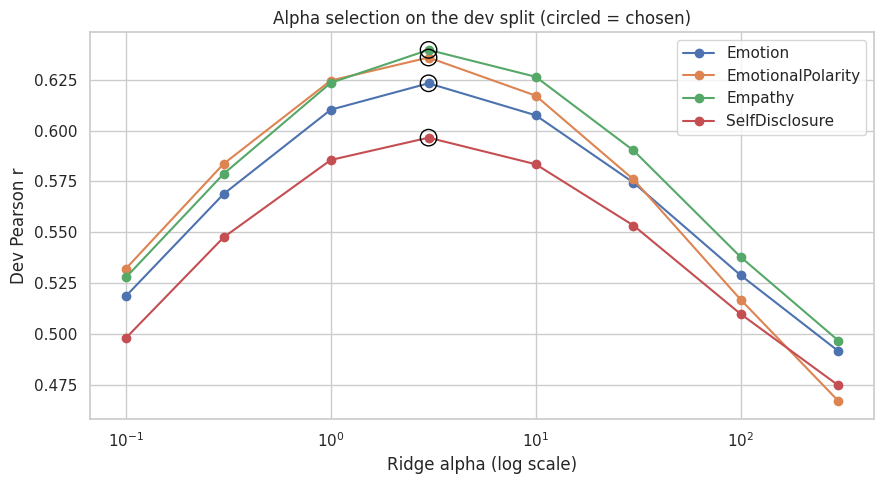

In [15]:
# Visualise the alpha sweep on dev (one line per target).
fig, ax = plt.subplots(figsize=(9, 5))
for target in TARGETS:
    sub = tuning[tuning["target"] == target]
    ax.plot(sub["alpha"], sub["dev_pearson"], marker="o", label=target)
    ax.scatter([alpha_choice[target]],
               [sub.loc[sub["alpha"] == alpha_choice[target], "dev_pearson"]],
               s=140, facecolors="none", edgecolors="black", zorder=5)
ax.set_xscale("log")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("Dev Pearson r")
ax.set_title("Alpha selection on the dev split (circled = chosen)")
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Trivial reference baselines

Two sanity baselines contextualise the Ridge scores:

- **Predict-the-mean** — always output the training mean of the target. Its
  Pearson r is undefined (the prediction is constant), and its R² is ~0 by
  construction; it exists to show the error floor a content-free model reaches.
- **Predict-per-speaker-mean** — output the training mean of the target for that
  speaker (`Person 1` / `Person 2`). This has two distinct predictions, so
  Pearson r is defined; if it were high, our r would be a speaker-role artifact
  rather than genuine text signal.

In [16]:
baseline_preds = {}

# predict-the-mean (per target)
train_means = {t: train[t].mean() for t in TARGETS}
baseline_preds["predict_mean"] = {
    t: np.full(len(test), train_means[t]) for t in TARGETS
}

# predict-per-speaker-mean (per target, keyed by 'Person 1' / 'Person 2')
speaker_means = {t: train.groupby("speaker")[t].mean() for t in TARGETS}
baseline_preds["predict_speaker_mean"] = {
    t: test["speaker"].map(speaker_means[t]).to_numpy() for t in TARGETS
}

print("Per-speaker training means:")
print(pd.DataFrame(speaker_means))

Per-speaker training means:
          Emotion  EmotionalPolarity  Empathy  SelfDisclosure
speaker                                                      
Person 1   2.1692             1.2804   2.0375          1.9175
Person 2   2.1995             1.2682   2.0776          1.9275


## 5 · Evaluate everything on the test split

In [17]:
records = []

# Ridge
for target in TARGETS:
    s = score_all(test[target], ridge_models[target].predict(X_test))
    records.append({"model": "tfidf_ridge", "target": target,
                    "alpha": alpha_choice[target], **s})

# reference baselines
for model_name, preds in baseline_preds.items():
    for target in TARGETS:
        s = score_all(test[target], preds[target])
        records.append({"model": model_name, "target": target,
                        "alpha": np.nan, **s})

metrics = pd.DataFrame(records)

# four-target averages per model
avg = (metrics.groupby("model")[["pearson", "mae", "r2"]]
              .mean().reset_index())
avg.insert(1, "target", "AVERAGE")
avg["alpha"] = np.nan
metrics = pd.concat([metrics, avg], ignore_index=True)

# tidy ordering
model_order = ["tfidf_ridge", "predict_speaker_mean", "predict_mean"]
target_order = TARGETS + ["AVERAGE"]
metrics["model"] = pd.Categorical(metrics["model"], model_order, ordered=True)
metrics["target"] = pd.Categorical(metrics["target"], target_order, ordered=True)
metrics = metrics.sort_values(["model", "target"]).reset_index(drop=True)
metrics

,model,target,alpha,pearson,mae,r2
0,tfidf_ridge,Emotion,3.0000,0.6623,0.5122,0.4261
1,tfidf_ridge,EmotionalPolarity,3.0000,0.6405,0.3767,0.4003
2,tfidf_ridge,Empathy,3.0000,0.6442,0.6062,0.4019
3,tfidf_ridge,SelfDisclosure,3.0000,0.6454,0.3919,0.4121
4,tfidf_ridge,AVERAGE,NaN,0.6481,0.4718,0.4101
5,predict_speaker_mean,Emotion,NaN,0.0395,0.6988,-0.0190
6,predict_speaker_mean,EmotionalPolarity,NaN,-0.0061,0.5229,-0.0110
7,predict_speaker_mean,Empathy,NaN,0.0405,0.8057,-0.0137
8,predict_speaker_mean,SelfDisclosure,NaN,0.0433,0.5376,-0.0041
9,predict_speaker_mean,AVERAGE,NaN,0.0293,0.6412,-0.0119


In [18]:
# The headline comparison: four-target average on test.
headline = (metrics[metrics["target"] == "AVERAGE"]
            .set_index("model")[["pearson", "mae", "r2"]])
print("Four-target average on TEST:\n")
print(headline)

out_path = RESULTS_DIR / "baseline_multi_target_test_metrics.csv"
metrics.to_csv(out_path, index=False)
print(f"\nSaved full metrics table -> {out_path.relative_to(REPO_ROOT)}")

Four-target average on TEST:

                      pearson    mae      r2
model                                       
tfidf_ridge            0.6481 0.4718  0.4101
predict_speaker_mean   0.0293 0.6412 -0.0119
predict_mean              NaN 0.6415 -0.0126

Saved full metrics table -> results/baseline_multi_target_test_metrics.csv


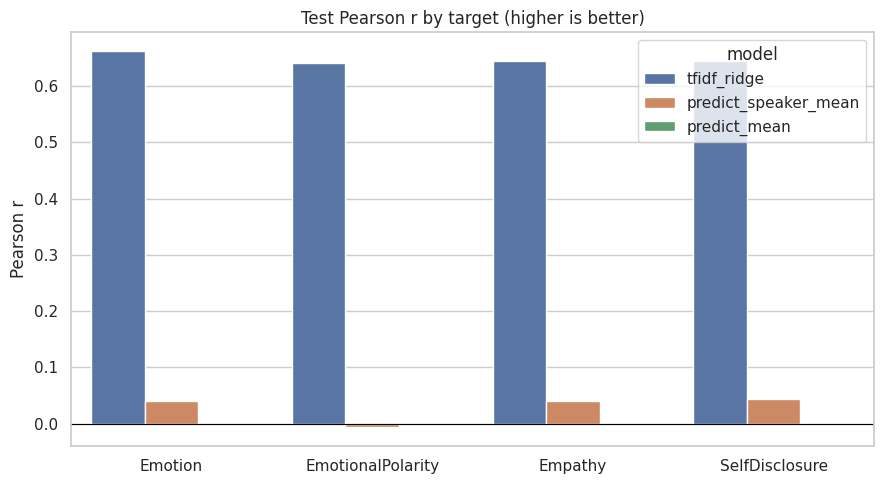

In [19]:
# Per-target Pearson r: Ridge vs the trivial baselines.
plot_df = metrics[metrics["target"] != "AVERAGE"].copy()
plot_df["target"] = plot_df["target"].astype(str)
plot_df["model"] = plot_df["model"].astype(str)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x="target", y="pearson", hue="model", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Test Pearson r by target (higher is better)")
ax.set_ylabel("Pearson r")
ax.set_xlabel("")
ax.legend(title="model", loc="upper right")
plt.tight_layout()
plt.show()

**Reading the result (RQ1).** The TF-IDF + Ridge model reaches a four-target
average Pearson r of roughly **0.65** on held-out conversations, and every
target lands in the **0.64-0.66** range. The two trivial baselines sit at
essentially **r ≈ 0** (predict-the-mean is undefined/constant; per-speaker-mean
≈ 0.03) and have **negative R²** on test. Their MAE is also clearly worse than
Ridge's. So the signal Ridge picks up is genuinely coming from the *words in the
turn*, not from the label distribution or from which speaker is talking — a
single utterance already carries substantial, predictable affect signal, and
this is the number the transformer must beat.

## 6 · Which words matter? (RQ3)

Because TF-IDF features are non-negative and Ridge is linear, the sign of each
coefficient says which direction an n-gram pushes the prediction. Below are the
strongest positive and negative n-grams per target.

In [20]:
TOP_K = 15
feature_rows = []

for target in TARGETS:
    coef = ridge_models[target].coef_
    order = np.argsort(coef)
    top_pos = order[-TOP_K:][::-1]
    top_neg = order[:TOP_K]
    for idx in top_pos:
        feature_rows.append({"target": target, "direction": "positive",
                             "feature": feature_names[idx], "coef": float(coef[idx])})
    for idx in top_neg:
        feature_rows.append({"target": target, "direction": "negative",
                             "feature": feature_names[idx], "coef": float(coef[idx])})

top_features = pd.DataFrame(feature_rows)
out_path = RESULTS_DIR / "ridge_top_features.csv"
top_features.to_csv(out_path, index=False)
print(f"Saved top features -> {out_path.relative_to(REPO_ROOT)}\n")

# Compact side-by-side view: top positive n-grams per target.
for target in TARGETS:
    pos = top_features[(top_features.target == target) &
                       (top_features.direction == "positive")]["feature"].tolist()
    print(f"{target:18s} +  {', '.join(pos[:10])}")

Saved top features -> results/ridge_top_features.csv

Emotion            +  terrible, sad, horrible, awful, scary, imagine, crazy, disgusting, evil, heartbreaking
EmotionalPolarity  +  sad, terrible, awful, imagine, scary, horrible, sadly, crazy, even, unfortunately
Empathy            +  sad, terrible, imagine, awful, poor, lost, horrible, tragedy, feel, hope
SelfDisclosure     +  my, and, me, to, but, never, am, myself, love, dog


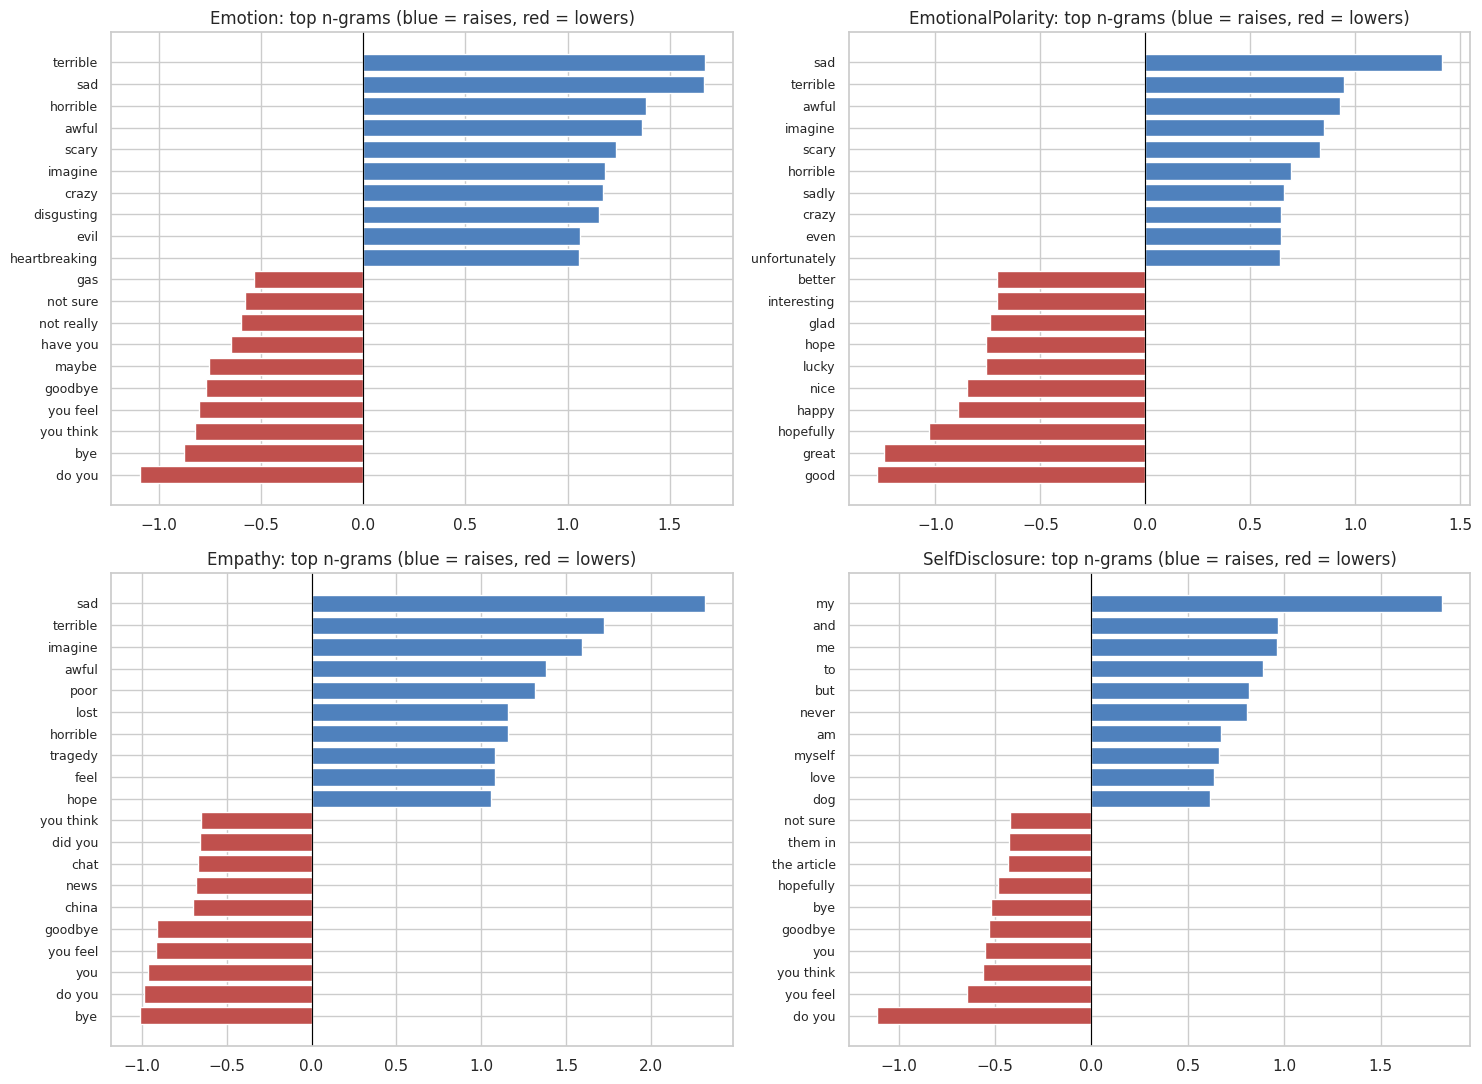

In [21]:
# Bar charts of the top +/- coefficients per target.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, target in zip(axes.flat, TARGETS):
    coef = ridge_models[target].coef_
    order = np.argsort(coef)
    idx = np.concatenate([order[:10], order[-10:]])
    vals = coef[idx]
    labels = feature_names[idx]
    colors = ["#c0504d" if v < 0 else "#4f81bd" for v in vals]
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{target}: top n-grams (blue = raises, red = lowers)")
plt.tight_layout()
plt.show()

In [22]:
# Save the multi-target metrics table for reference.
metrics.to_csv(RESULTS_DIR / 'baseline_multi_target_results.csv', index=False)
print('Saved multi-target metrics to results/baseline_multi_target_results.csv')


Saved multi-target metrics to results/baseline_multi_target_results.csv


**Reading the coefficients (RQ3).** The features are intuitive and act as a
face-validity check on the whole pipeline:

- **Emotion** rises on charged words (*sad, terrible, horrible, awful, scary,
  disgusting*) and falls on turn-closers and questions (*bye, goodbye, do you,
  you think*).
- **EmotionalPolarity** rises on *negative* words (*sad, terrible, awful,
  unfortunately*) and falls on *positive* ones (*good, great, happy, glad,
  lucky, hope*). This confirms the orientation established in `01_eda`: **higher
  polarity = more negative** in this corpus.
- **Empathy** rises on other-directed, feeling words (*sad, imagine, poor, feel,
  lost*) and falls on logistics/closings (*bye, goodbye, news, chat*).
- **SelfDisclosure** rises on first-person markers (*my, me, myself, I am*) and
  falls on second-person / other-directed phrasing (*do you, you feel, you
  think*) — exactly what "disclosing about oneself" should look like.

**Caveats.** This is a deliberately simple floor: it is bag-of-n-grams, so it
ignores word order beyond bigrams and all conversational context (the previous
turns), both of which the transformer can exploit. The scores above are on an
internal conversation-grouped split, not the official leaderboard split, so they
are only directly comparable to models evaluated the same way — treat them as a
same-split reference point, not an official number.